<a href="https://colab.research.google.com/github/Kartikey9936/Deep-Learning/blob/main/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
root_dir = r'sketches'
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 20
NUM_EPOCHS = 10
LEARNING_RATE = 2e-4

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
transform = v2.Compose([
    v2.Resize((IMG_HEIGHT, IMG_WIDTH)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [ ]:
dataset = ImageFolder(root_dir, transform=transform)
print(f'The number of classes is {len(dataset.classes)}')
print(f'The number of images is {len(dataset)}')

The number of classes is 250
The number of images is 20000


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f'The number of training images is {len(train_dataset)}')
print(f'The number of validation images is {len(val_dataset)}')

The number of training images is 16000
The number of validation images is 4000


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f'The number of batches in the training set is {len(train_loader)}')
print(f'The number of batches in the validation set is {len(val_loader)}')

The number of batches in the training set is 800
The number of batches in the validation set is 200


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([20, 3, 128, 128])
torch.Size([20])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3960784..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6392157..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.31764704..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4823529..1.0].


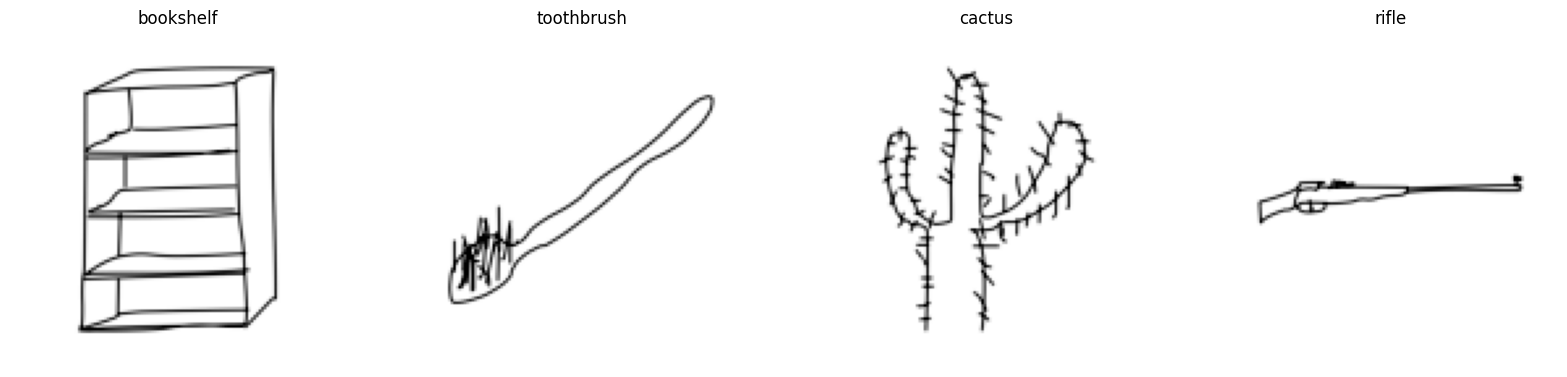

In [ ]:
plt.figure(figsize=(20, 20))
for i in range(4):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
    plt.title(f'{dataset.classes[labels[i]]}')
    plt.axis('off')
plt.show()

In [ ]:
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import copy
import numpy as np

In [ ]:
def get_model(num_classes):
    model = models.resnet152(weights='DEFAULT')
    #model = models.resnet151(weights='DEFAULT')

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloader):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset) * 100

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.cpu())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.cpu())
                scheduler.step(epoch_loss)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)

    # Return the model and training history
    return model, {'train_loss': train_losses, 'val_loss': val_losses,
                  'train_acc': train_accs, 'val_acc': val_accs}

In [ ]:
num_classes = len(dataset.classes)
model = get_model(num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

model, history = train_model(model, criterion, optimizer, scheduler, NUM_EPOCHS)

Epoch 1/10
----------


100%|██████████| 800/800 [04:22<00:00,  3.05it/s]


train Loss: 2.3327 Acc: 46.5500


100%|██████████| 200/200 [01:27<00:00,  2.29it/s]


val Loss: 1.2089 Acc: 66.8750

Epoch 2/10
----------


...

val Loss: 0.9622 Acc: 79.3000

Epoch 10/10
----------


100%|██████████| 800/800 [03:09<00:00,  4.23it/s]


train Loss: 0.0034 Acc: 99.9813


100%|██████████| 200/200 [00:40<00:00,  4.98it/s]

val Loss: 0.9534 Acc: 79.4500

Training complete in 49m 14s
Best val Acc: 79.4500


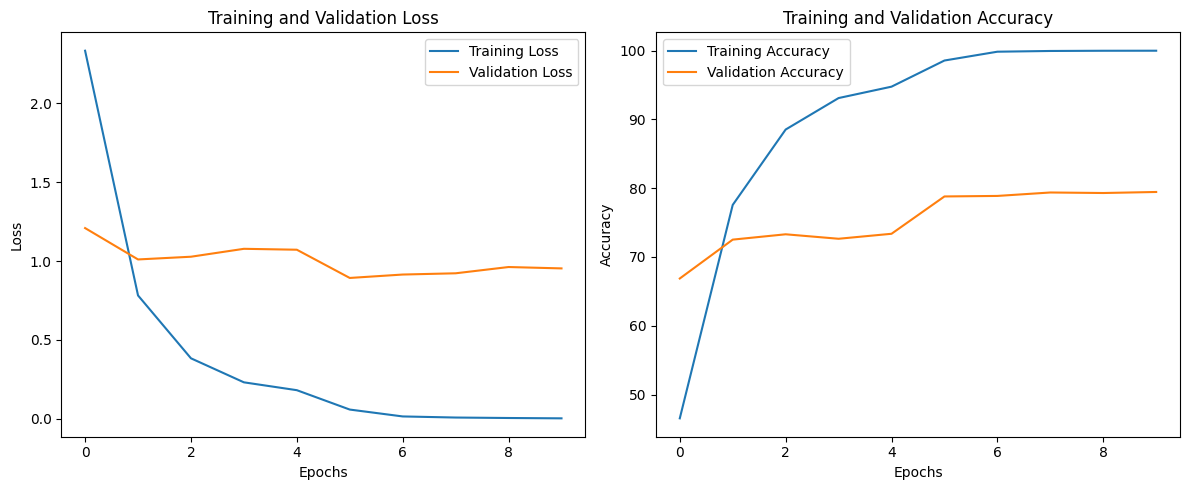

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([acc.numpy() for acc in history['train_acc']], label='Training Accuracy')
plt.plot([acc.numpy() for acc in history['val_acc']], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

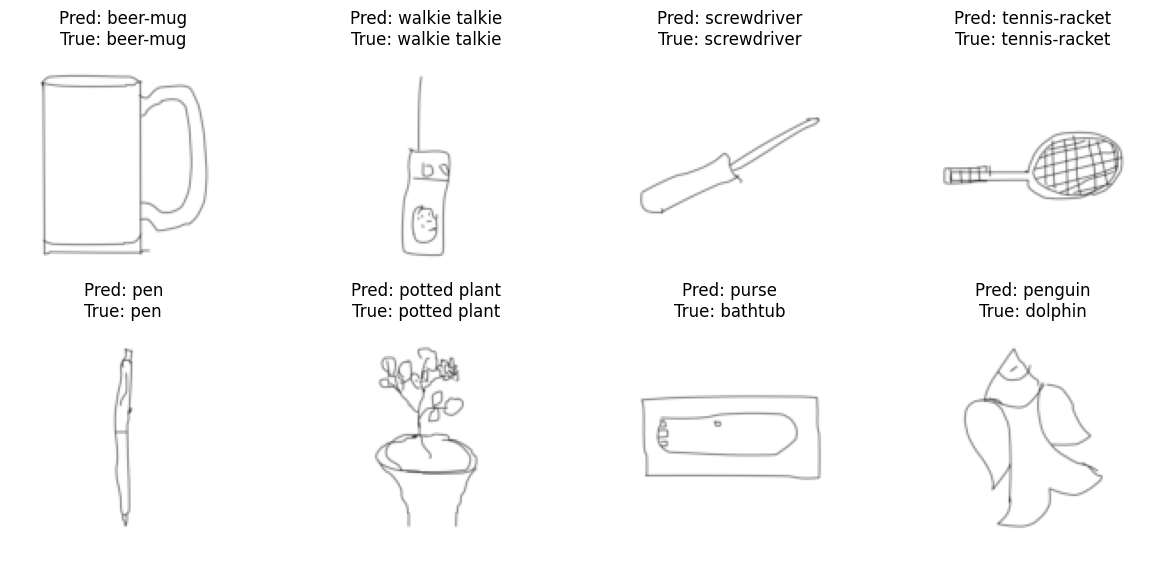

In [ ]:

def visualize_predictions(model, dataloader, num_images=8):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1

                if images_so_far <= num_images:
                    ax = plt.subplot(num_images//4 + 1, 4, images_so_far)
                    ax.axis('off')
                    ax.set_title(f'Pred: {dataset.classes[preds[j]]}\nTrue: {dataset.classes[labels[j]]}')

                    img = inputs[j].cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5
                    plt.imshow(img)

                if images_so_far == num_images:
                    return

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader)

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'classes': dataset.classes
}, 'resnet151_sketches_model.pth')

print("Model saved successfully!")


Model saved successfully!
